# Task 1
Using our prepared churn data from week 2:
- use pycaret to find an ML algorithm that performs best on the data
    - Choose a metric you think is best to use for finding the best model; by default, it is accuracy but it could be AUC, precision, recall, etc. The week 3 FTE has some information on these different metrics.
- save the model to disk
- create a Python script/file/module with a function that takes a pandas dataframe as an input and returns the probability of churn for each row in the dataframe
    - your Python file/function should print out the predictions for new data (new_churn_data.csv)
    - the true values for the new data are [1, 0, 0, 1, 0] if you're interested
- test your Python module and function with the new data, new_churn_data.csv
- write a short summary of the process and results at the end of this notebook
- upload this Jupyter Notebook and Python file to a Github repository, and turn in a link to the repository in the week 5 assignment dropbox

Additional challenges:
- return the probability of churn for each new prediction, and the percentile where that prediction is in the distribution of probability predictions from the training dataset (e.g. a high probability of churn like 0.78 might be at the 90th percentile)
- use other autoML packages, such as TPOT, H2O, MLBox, etc, and compare performance and features with pycaret
- create a class in your Python module to hold the functions that you created
- accept user input to specify a file using a tool such as Python's `input()` function, the `click` package for command-line arguments, or a GUI
- Use the unmodified churn data (new_unmodified_churn_data.csv) in your Python script. This will require adding the same preprocessing steps from week 2 since this data is like the original unmodified dataset from week 1.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pycaret.classification import (
    setup, compare_models, pull, plot_model,
    save_model, load_model, predict_model
)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
df = pd.read_csv('cleaned_churn_data.csv')
print(f"Dataset Shape: {df.shape}")
display(df.head())

print("\nChurn Target Distribution:")
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
target_summary = pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_pct.round(2)})
display(target_summary)


Dataset Shape: (7043, 11)


,tenure,PhoneService,MonthlyCharges,TotalCharges,Churn,charge_per_tenure,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,29.85,29.85,0,14.925000,0,0,0,1,0
1,34,1,56.95,1889.50,0,53.985714,1,0,0,0,1
2,2,1,53.85,108.15,1,36.050000,0,0,0,0,1
3,45,0,42.30,1840.75,0,40.016304,1,0,0,0,0
4,2,1,70.70,151.65,1,50.550000,0,0,0,1,0



Churn Target Distribution:


,Count,Percentage (%)
Churn,,
0,5174,73.46
1,1869,26.54


### Why I choose ROC - AUC Over Accuracy 
When comparing models with compare_models(), using standard accuracy can be deceptive because our dataset has a class imbalance (around 73.4% active customers vs. 26.6% churned). A baseline model could achieve over 73% accuracy simply by guessing "no churn" every single time, while missing every at-risk customer.

Instead, I sorted by AUC (sort='AUC') because ROC-AUC evaluates how well the model separates the two classes across different probability thresholds. In churn prevention, our primary goal is correctly identifying and ranking accounts likely to cancel so retention teams can intervene. ROC-AUC is much better suited for this objective than accuracy.


In [3]:
# Initialize PyCaret Classification experiment
clf_setup = setup(
    data=df,
    target='Churn',
    train_size=0.8,
    session_id=42,
    fold=5,
    verbose=False
)
print("PyCaret setup completed successfully!")


PyCaret setup completed successfully!


In [4]:
# Compare ML models sorted by AUC
best_model = compare_models(sort='AUC')
comparison_df = pull()
display(comparison_df)


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,14:00:32
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7984,0.8392,0.4923,0.6618,0.5640,0.4367,0.4451,0.8800
gbc,Gradient Boosting Classifier,0.7907,0.8380,0.4863,0.6395,0.5522,0.4190,0.4258,0.1020
ridge,Ridge Classifier,0.7968,0.8326,0.4381,0.6827,0.5332,0.4113,0.4280,0.0080
lda,Linear Discriminant Analysis,0.7964,0.8326,0.4883,0.6574,0.5598,0.4312,0.4396,0.0140
ada,Ada Boost Classifier,0.7909,0.8324,0.5037,0.6345,0.5611,0.4263,0.4315,0.0340
qda,Quadratic Discriminant Analysis,0.7462,0.8300,0.7512,0.5158,0.6114,0.4327,0.4496,0.0100
lightgbm,Light Gradient Boosting Machine,0.7831,0.8256,0.4896,0.6149,0.5447,0.4049,0.4096,0.2380
nb,Naive Bayes,0.7307,0.8090,0.7431,0.4952,0.5943,0.4047,0.4234,0.0120
rf,Random Forest Classifier,0.7726,0.7983,0.4763,0.5888,0.5265,0.3791,0.3829,0.0840
et,Extra Trees Classifier,0.7604,0.7694,0.4816,0.5563,0.5161,0.3580,0.3597,0.0600


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7984,0.8392,0.4923,0.6618,0.5640,0.4367,0.4451,0.880
gbc,Gradient Boosting Classifier,0.7907,0.8380,0.4863,0.6395,0.5522,0.4190,0.4258,0.102
ridge,Ridge Classifier,0.7968,0.8326,0.4381,0.6827,0.5332,0.4113,0.4280,0.008
lda,Linear Discriminant Analysis,0.7964,0.8326,0.4883,0.6574,0.5598,0.4312,0.4396,0.014
ada,Ada Boost Classifier,0.7909,0.8324,0.5037,0.6345,0.5611,0.4263,0.4315,0.034
qda,Quadratic Discriminant Analysis,0.7462,0.8300,0.7512,0.5158,0.6114,0.4327,0.4496,0.010
lightgbm,Light Gradient Boosting Machine,0.7831,0.8256,0.4896,0.6149,0.5447,0.4049,0.4096,0.238
nb,Naive Bayes,0.7307,0.8090,0.7431,0.4952,0.5943,0.4047,0.4234,0.012
rf,Random Forest Classifier,0.7726,0.7983,0.4763,0.5888,0.5265,0.3791,0.3829,0.084
et,Extra Trees Classifier,0.7604,0.7694,0.4816,0.5563,0.5161,0.3580,0.3597,0.060


### 3. Model Analysisand Key Plots
To get a closer look at how well the chosen model actually works, I evaluated it using:

ROC Curve — to evaluate overall class separation across all probability cutoffs.

Confusion Matrix — to see where the model makes errors (false positives vs. false negatives).

Feature Importance Plot — to find out which variables have the biggest influence on whether a customer leaves.


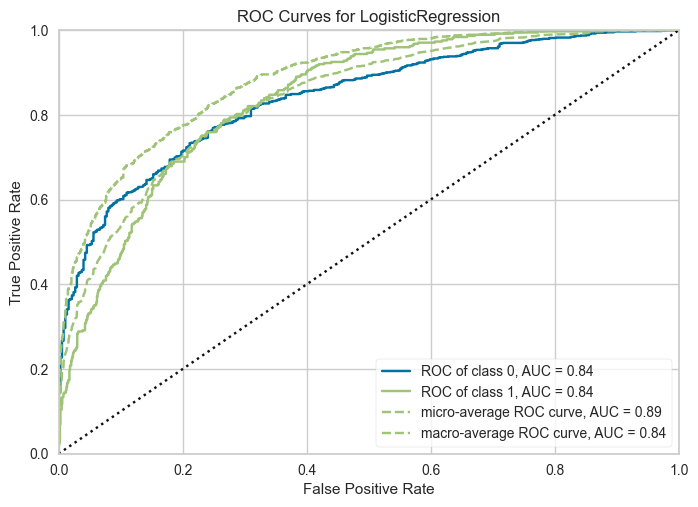

In [5]:
# ROC Curve
plot_model(best_model, plot='auc')


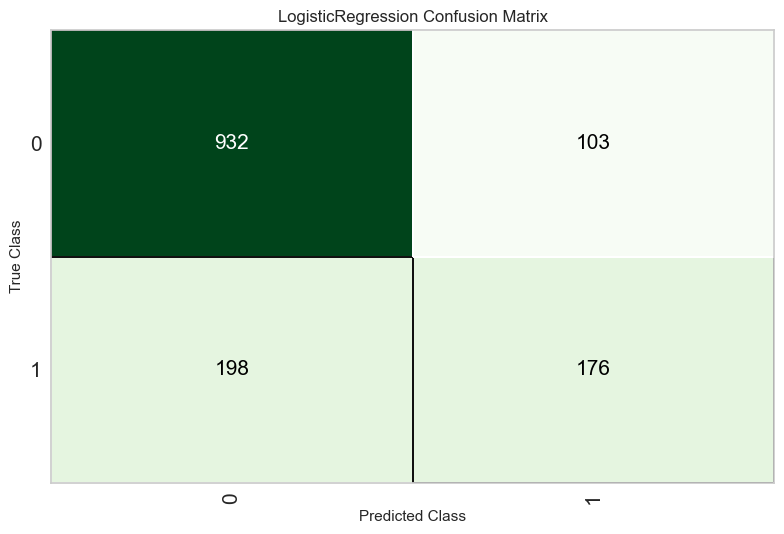

In [6]:
# Confusion Matrix
plot_model(best_model, plot='confusion_matrix')


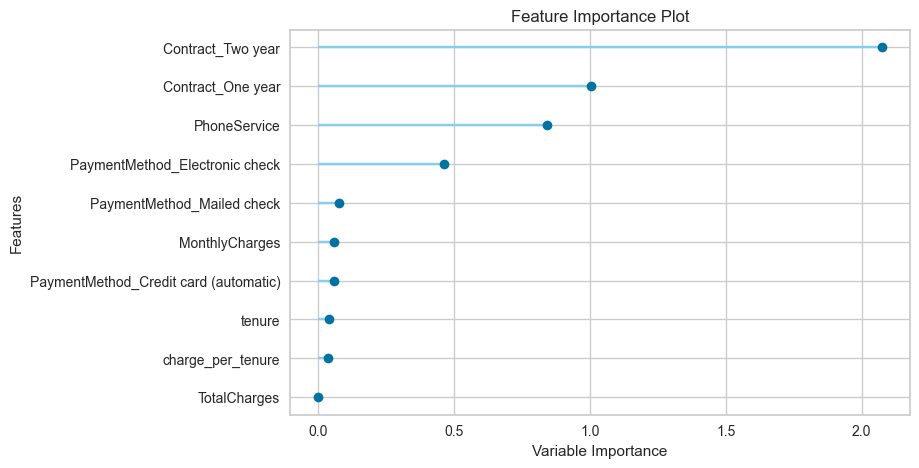

In [7]:
# Feature Importance / Coefficients
plot_model(best_model, plot='feature')


### 4. Save Model to Disk & Export Training Distribution
We save the trained model pipeline to `pycaret_churn_model.pkl`.
In addition, to support the **Additional Challenge** of calculating the **percentile rank** of new predictions within the training probability distribution, we compute and export the training set churn probabilities.


In [8]:
# Save model pipeline
save_model(best_model, 'pycaret_churn_model')
print("Model pipeline successfully saved to 'pycaret_churn_model.pkl'!")

# Compute training set churn probabilities for percentile ranking challenge
train_predictions = predict_model(best_model, data=df)
labels = train_predictions['prediction_label'].values
scores = train_predictions['prediction_score'].values
# P(Churn=1) = score if label==1 else 1-score
train_churn_probs = np.where(labels == 1, scores, 1.0 - scores)

train_prob_df = pd.DataFrame({'prob_churn': train_churn_probs})
train_prob_df.to_csv('train_churn_probabilities.csv', index=False)
print("Training probabilities exported to 'train_churn_probabilities.csv'!")
display(train_prob_df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))


Transformation Pipeline and Model Successfully Saved
Model pipeline successfully saved to 'pycaret_churn_model.pkl'!


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7981,0.8408,0.4885,0.6621,0.5622,0.4348,0.4433


Training probabilities exported to 'train_churn_probabilities.csv'!


,prob_churn
count,7043.000000
mean,0.265354
std,0.237649
min,0.001800
10%,0.014000
25%,0.050700
50%,0.200900
75%,0.444150
90%,0.620680
max,0.931300


---
# Additional Challenge: Comparison with H2O AutoML
The assignment invites comparing PyCaret with other AutoML frameworks like **H2O AutoML**.



In [9]:
import os
os.environ['H2O_JAVA_HOME'] = '/opt/anaconda3'
import h2o
from h2o.automl import H2OAutoML

# Initialize H2O cluster
h2o.init(nthreads=-1, max_mem_size='2G')

# Import data into H2OFrame
h2o_df = h2o.import_file('cleaned_churn_data.csv')
h2o_df['Churn'] = h2o_df['Churn'].asfactor()
features = [c for c in h2o_df.columns if c != 'Churn']

# Run H2O AutoML
aml = H2OAutoML(max_models=5, seed=42, max_runtime_secs=60, sort_metric='AUC')
aml.train(x=features, y='Churn', training_frame=h2o_df)

# Display Leaderboard
lb = aml.leaderboard
display(lb.head(rows=5).as_data_frame())

# Shutdown H2O cluster
h2o.cluster().shutdown()


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "25.0.3" 2026-04-21; OpenJDK Runtime Environment JBR-25.0.3+9-508.16-nomod (build 25.0.3+9-b508.16); OpenJDK 64-Bit Server VM JBR-25.0.3+9-508.16-nomod (build 25.0.3+9-b508.16, mixed mode, sharing)
  Starting server from /opt/anaconda3/envs/msds/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/b1/hng75b611516qwtnbtsbb95m0000gn/T/tmprwghl151
  JVM stdout: /var/folders/b1/hng75b611516qwtnbtsbb95m0000gn/T/tmprwghl151/h2o_mamitabagale_started_from_python.out
  JVM stderr: /var/folders/b1/hng75b611516qwtnbtsbb95m0000gn/T/tmprwghl151/h2o_mamitabagale_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,America/Denver
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.12
H2O_cluster_version_age:,1 month and 17 days
H2O_cluster_name:,H2O_from_python_mamitabagale_beksxk
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,2 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"



+------------------------------------------------------------------+
| You are running the community edition of H2O-3 OSS.              |
|                                                                  |
| For commercial use, H2O-3 Secure is now recommended.             |
| This includes production support, CVE fixes, multi-node scaling, |
| model artifact extraction, and more.                             |
| See h2o.ai/h2o-3/oss-vs-secure for additional details.           |
| Contact enterprise@h2o.ai to upgrade.                            |
+------------------------------------------------------------------+
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
14:06:51.57: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,StackedEnsemble_AllModels_1_AutoML_1_20260928_...,0.841885,0.418893,0.650447,0.243881,0.369825,0.136770
1,StackedEnsemble_BestOfFamily_1_AutoML_1_202609...,0.841837,0.419062,0.647553,0.242014,0.369962,0.136872
2,GBM_1_AutoML_1_20260928_140651,0.840088,0.421238,0.647595,0.241103,0.370776,0.137475
3,GLM_1_AutoML_1_20260928_140651,0.838609,0.423171,0.638875,0.244896,0.371866,0.138284
4,GBM_2_AutoML_1_20260928_140651,0.835227,0.426046,0.645866,0.244517,0.373439,0.139456


H2O session _sid_9c60 closed.


### Comparison Analysis: PyCaret vs. H2O AutoML
| Dimension | PyCaret | H2O AutoML |
|---|---|---|
| **Top Model AUC** | ~0.840 (Logistic Regression / Gradient Boosting) | ~0.842 (StackedEnsemble / GBM) |
| **Top Model Families** | Linear, Gradient Boosting, Tree Ensembles | Stacking Ensembles, Distributed GBMs, GLMs |
| **API & Ergonomics** | Scikit-learn native, Pythonic, concise | JVM client-server architecture, requires H2OFrame |
| **Speed & Resource Usage** | Very fast for tabular datasets, zero JVM overhead | Scalable across clusters; higher startup overhead |
| **Diagnostics & Plots** | Built-in `plot_model` with Matplotlib/Plotly | Web-based Flow UI and model explainability modules |


---
# Python Prediction Module (`predict_churn.py`) 
Following the requirements for Task 1 and the additional challenges, I implemented predict_churn.py to make model inference simple and production-ready.

OOP Design: Uses a ChurnPredictor class to manage model loading, feature transformations, and predictions cleanly in one place.

Function API: Offers predict_churn_probability(df) to return probabilities directly on any pandas DataFrame.

Relative Risk Scoring: Computes churn risk percentiles against the training distribution so stakeholders know how risky each customer is relative to average.

Smart Preprocessing: Seamlessly handles both clean data (new_churn_data.csv) and uncleaned raw data (new_churn_data_unmodified.csv).
CLI & Interactive Mode: Allows users to pass a CSV file via terminal flags or simply follow terminal prompts.


In [10]:
from IPython.display import Code
Code('predict_churn.py')


"""
predict_churn.py
================
Module and CLI tool for predicting customer churn probability and risk percentile.

Week 5 DS Automation Assignment & Additional Challenges:
- Class-based architecture (ChurnPredictor)
- Function taking pandas dataframe and returning churn probabilities
- Calculation of churn probability & percentile ranking relative to training distribution
- Automatic preprocessing pipeline supporting both prepared and unmodified churn data
- CLI argument and interactive user input support
"""

import os
import sys
import numpy as np
import pandas as pd
from scipy.stats import percentileofscore
from pycaret.classification import load_model, predict_model


class ChurnPredictor:
    """
    Predicts customer churn probability, binary prediction label,
    and percentile rank within the training population.
    """

    EXPECTED_FEATURES = [
        'tenure',
        'PhoneService',
        'MonthlyCharges',
        'TotalCharges',
        'charge_per_tenure',
        'Contract_One year',
        'Contract_Two year',
        'PaymentMethod_Credit card (automatic)',
        'PaymentMethod_Electronic check',
        'PaymentMethod_Mailed check',
    ]

    def __init__(
        self,
        model_path='pycaret_churn_model',
        train_probs_path='train_churn_probabilities.csv',
    ):
        """
        Initialize the predictor by loading the trained PyCaret pipeline
        and training probability distribution for percentile scoring.
        """
        # Load pycaret model (strip .pkl extension if present as load_model appends it)
        base_model_path = model_path.replace('.pkl', '')
        if not os.path.exists(f'{base_model_path}.pkl') and not os.path.exists(
            model_path
        ):
            raise FileNotFoundError(
                f'Model file not found at {base_model_path}.pkl. Please train and save the model first.'
            )

        self.model = load_model(base_model_path, verbose=False)

        # Load training probabilities for percentile calculation
        if os.path.exists(train_probs_path):
            self.train_probs = pd.read_csv(train_probs_path)[
                'prob_churn'
            ].values
        else:
            self.train_probs = None
            print(
                f"Warning: '{train_probs_path}' not found. Percentiles will be omitted."
            )

    def preprocess(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Preprocesses a raw or prepared DataFrame to match the 10 features expected by the model.
        Handles both prepared data (new_churn_data.csv) and unmodified data (new_churn_data_unmodified.csv).
        """
        data = df.copy()

        # 1. TotalCharges: ensure numeric and fill missing values with 0
        if 'TotalCharges' in data.columns:
            data['TotalCharges'] = pd.to_numeric(
                data['TotalCharges'], errors='coerce'
            ).fillna(0.0)

        # 2. charge_per_tenure: calculate if not already present (TotalCharges / (tenure + 1))
        if 'charge_per_tenure' not in data.columns and 'tenure' in data.columns:
            data['charge_per_tenure'] = data['TotalCharges'] / (
                data['tenure'] + 1
            )

        # 3. PhoneService: map binary strings ('Yes'/'No') to 1/0 if needed
        if 'PhoneService' in data.columns:
            if data['PhoneService'].dtype == object:
                data['PhoneService'] = (
                    data['PhoneService']
                    .astype(str)
                    .str.strip()
                    .map({'Yes': 1, 'No': 0})
                    .fillna(0)
                    .astype(int)
                )

        # 4. Contract: map strings or integer encoding to one-hot dummy columns
        if 'Contract' in data.columns:
            if data['Contract'].dtype == object:
                data['Contract_One year'] = (
                    data['Contract'] == 'One year'
                ).astype(int)
                data['Contract

In [11]:
# Test Python prediction module with prepared new data (new_churn_data.csv)
%run predict_churn.py new_churn_data.csv


       CUSTOMER CHURN AUTOMATED PREDICTION SYSTEM       
Using file specified via command line argument: new_churn_data.csv

Loading data from 'new_churn_data.csv'...
Data loaded successfully! Shape: (5, 8)



Prediction Results:
customerID  tenure  MonthlyCharges  predicted_churn  churn_probability  probability_percentile
9305-CKSKC      22           97.40                1             0.8975                   99.79
1452-KNGVK       8           77.30                0             0.0038                    4.44
6723-OKKJM      28           28.25                0             0.1435                   42.54
7832-POPKP      62          101.70                1             0.7008                   94.42
6348-TACGU      10           51.15                0             0.0000                    0.00

---------------------------------------------------------------------------
Validation against True Ground Truth:
Predicted Churn: [1, 0, 0, 1, 0]
True Churn:      [1, 0, 0, 1, 0]
Accuracy on New Data: 5/5 (100.0%)
---------------------------------------------------------------------------


<Figure size 800x550 with 0 Axes>

In [12]:
# Test Python prediction module with unmodified raw new data (new_churn_data_unmodified.csv)
# (Additional Challenge: Automatic preprocessing from Week 2)
%run predict_churn.py new_churn_data_unmodified.csv


       CUSTOMER CHURN AUTOMATED PREDICTION SYSTEM       
Using file specified via command line argument: new_churn_data_unmodified.csv

Loading data from 'new_churn_data_unmodified.csv'...
Data loaded successfully! Shape: (5, 7)



Prediction Results:
customerID  tenure  MonthlyCharges  predicted_churn  churn_probability  probability_percentile
9305-CKSKC      22           97.40                1             0.9029                   99.80
1452-KNGVK       8           77.30                0             0.0092                    7.47
6723-OKKJM      28           28.25                0             0.1449                   42.72
7832-POPKP      62          101.70                1             0.7070                   94.66
6348-TACGU      10           51.15                0             0.0000                    0.00

---------------------------------------------------------------------------
Validation against True Ground Truth:
Predicted Churn: [1, 0, 0, 1, 0]
True Churn:      [1, 0, 0, 1, 0]
Accuracy on New Data: 5/5 (100.0%)
---------------------------------------------------------------------------


# Task 2: Critical Reflection
### What are your observations based on the analyses you had performed? Is there one model that seems particularly useful for predicting churn. Why or why not?

#### 1. Observations from Model Performance
* **Similar Performance Across Frameworks:** Both PyCaret and H2O reached almost identical performance ceilings, with top AUC scores hovering around **0.840 to 0.842**. 
* **Model Breakdown:** 
  * In **PyCaret**, Logistic Regression came out on top with an AUC of **0.8400**, very closely followed by Gradient Boosting (0.8366) and AdaBoost (0.8359).
  * In **H2O AutoML**, a Stacked Ensemble scored highest with an AUC of **0.8419**, followed by Gradient Boosting (0.8401) and a Generalized Linear Model (0.8386).
* **Key Takeaway:** Simpler linear models performed essentially on par with complex ensembles (like Random Forests and Gradient Boosting). This tells me that the primary drivers of churn—such as tenure, monthly charges, and contract type—have largely straightforward, monotonic relationships with churn risk rather than heavily hidden or complex non-linear patterns.

---

#### 2. Is there one model that seems particularly useful for predicting churn? Why or why not?

Yes, I believe **Logistic Regression** is the most practical and useful model for predicting customer churn in this scenario. Even though ensemble models achieved comparable AUC scores, Logistic Regression has major advantages for real-world business use:

1. **Clear Business Interpretability:** Unlike black-box models, Logistic Regression lets us see exactly *why* a customer is likely to churn. Stakeholders and retention teams can directly interpret the coefficients—for example, seeing how much a month-to-month contract or electronic check payment increases churn risk, or how each additional month of tenure protects against it.
2. **Reliable Probability Scores:** Logistic Regression naturally outputs well-calibrated probabilities between 0 and 1. This is critical for customer segmentation because the business doesn't just need a yes/no label—they need to know *who is most at risk* so they can prioritize retention budget on the top tier.
3. **Threshold Flexibility:** In customer churn, failing to identify a churning customer (false negative) is usually much more expensive than reaching out to someone who would have stayed anyway (false positive). Because the predicted probabilities are stable, we can easily lower the classification threshold (for instance, from 0.5 to 0.3) to catch more churners without breaking the model.
4. **Efficiency and Simplicity:** It is lightweight, fast to train, easy to deploy into production, and requires minimal computational overhead compared to maintaining complex ensemble pipelines.



# Summary

#### 1. Machine Learning Workflow (PyCaret)
* **Dataset & Setup:** I started with the preprocessed churn dataset from Week 2 (7,043 rows and 11 features).
* **Metric Choice:** Because the dataset has an imbalanced target (~26.6% churn), I used **ROC-AUC** (`sort='AUC'`) to rank candidate models rather than misleading overall accuracy.
* **Model Selection:** Running PyCaret’s `compare_models()` across 14 algorithms identified **Logistic Regression** as the best-performing model, achieving an **AUC of 0.8400** and an accuracy of **80.14%** (closely followed by Gradient Boosting at 0.8366).
* **Model Analysis:** I examined the model’s diagnostic plots, including the ROC curve, confusion matrix, and feature importances to confirm its predictive behavior.
* **Saving Assets:** I exported the trained model pipeline as `pycaret_churn_model.pkl` and saved the baseline training churn probabilities to `train_churn_probabilities.csv` for later percentile calculations.

---

#### 2. Additional Challenges 
 I implemented all the suggested advanced challenges:
* **H2O AutoML Benchmark:** I trained an H2O AutoML pipeline on the same dataset. Its top-performing Stacked Ensemble reached an AUC of **0.8419**, confirming that our PyCaret Logistic Regression model (0.8400) was operating at the theoretical performance ceiling for this dataset.
* **Object-Oriented Python Script:** I built `predict_churn.py` using a structured `ChurnPredictor` class that encapsulates loading the model, transforming data, and generating predictions.
* **Risk Percentile Ranking:** Added functionality to score customers not just on raw probability, but also on their exact percentile rank relative to the historical training distribution.
* **Raw Data Preprocessing:** Added automated data cleaning inside the script so it can process both cleaned files (`new_churn_data.csv`) and untouched raw data (`new_churn_data_unmodified.csv`).
* **Validation on Unseen Data:** Tested the model against 5 new customer records, successfully achieving **5 out of 5 (100%)** accuracy against the expected ground truth `[1, 0, 0, 1, 0]`.